<a href="https://colab.research.google.com/github/huanbv/BVU.CaoHoc.BuiVanHuan-TriTueNhanTaoNangCao_UngDung/blob/main/Lab_Quinlan_ThucHanh_ChiTiet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

BƯỚC 0 — Cài đặt thư viện

In [1]:
import pandas as pd
import numpy as np
from itertools import combinations

pd.set_option('display.max_columns', None)
print("Đã import xong các thư viện cần thiết ✅")

Đã import xong các thư viện cần thiết ✅


BƯỚC 1 — Khởi tạo dữ liệu huấn luyện

In [2]:
data = {
    "Ten":      ["Sarah", "Dana", "Alex", "Annie", "Emilie", "Peter", "John", "Kartie"],
    "Toc":      ["Vang",  "Vang", "Nau",  "Vang",  "Do",     "Nau",   "Nau",  "Vang"],
    "ChieuCao": ["TBinh", "Cao",  "Thap", "Thap",  "TBinh",  "Cao",   "TBinh","Thap"],
    "CanNang":  ["Nhe",   "TBinh","TBinh","TBinh", "Nang",   "Nang",  "Nang", "Nhe"],
    "DungKem":  ["Khong", "Co",   "Co",   "Khong", "Khong",  "Khong", "Khong","Co"],
    "KetQua":   ["Chay",  "Khong","Khong","Chay",  "Chay",   "Khong", "Khong","Khong"],
}

df = pd.DataFrame(data).set_index("Ten")

TARGET = "KetQua"
ATTRIBUTES = ["Toc", "ChieuCao", "CanNang", "DungKem"]
CLASSES = sorted(df[TARGET].unique())   # ['Chay', 'Khong'] -> tương ứng (r1, r2)

print(f"Tổng số mẫu: {len(df)} | Các lớp mục tiêu: {CLASSES}")
df

Tổng số mẫu: 8 | Các lớp mục tiêu: ['Chay', 'Khong']


,Toc,ChieuCao,CanNang,DungKem,KetQua
Ten,,,,,
Sarah,Vang,TBinh,Nhe,Khong,Chay
Dana,Vang,Cao,TBinh,Co,Khong
Alex,Nau,Thap,TBinh,Co,Khong
Annie,Vang,Thap,TBinh,Khong,Chay
Emilie,Do,TBinh,Nang,Khong,Chay
Peter,Nau,Cao,Nang,Khong,Khong
John,Nau,TBinh,Nang,Khong,Khong
Kartie,Vang,Thap,Nhe,Co,Khong


BƯỚC 2 — Chuẩn hóa & kiểm tra dữ liệu

In [3]:
print("Số giá trị thiếu theo từng cột:")
print(df.isnull().sum())

print(f"\nThứ tự lớp cố định dùng cho Vector Đặc Trưng: {CLASSES}")
print(f"  r1 = {CLASSES[0]}   |   r2 = {CLASSES[1]}")

print("\nThống kê lớp mục tiêu:")
print(df[TARGET].value_counts())

print("\nCác giá trị có thể của từng thuộc tính:")
for attr in ATTRIBUTES:
    print(f"  - {attr}: {sorted(df[attr].unique())}")

Số giá trị thiếu theo từng cột:
Toc         0
ChieuCao    0
CanNang     0
DungKem     0
KetQua      0
dtype: int64

Thứ tự lớp cố định dùng cho Vector Đặc Trưng: ['Chay', 'Khong']
  r1 = Chay   |   r2 = Khong

Thống kê lớp mục tiêu:
KetQua
Khong    5
Chay     3
Name: count, dtype: int64

Các giá trị có thể của từng thuộc tính:
  - Toc: ['Do', 'Nau', 'Vang']
  - ChieuCao: ['Cao', 'TBinh', 'Thap']
  - CanNang: ['Nang', 'Nhe', 'TBinh']
  - DungKem: ['Co', 'Khong']


BƯỚC 3 — Cài đặt Vector Đặc Trưng V_A(j)

In [4]:
def feature_vector(data, attribute, target, classes):
    '''Trả về dict {gia_tri_thuoc_tinh: (T(j,r1), T(j,r2), ...)}'''
    vectors = {}
    for value in data[attribute].unique():
        subset = data[data[attribute] == value]
        n_j = len(subset)
        vectors[value] = tuple(
            len(subset[subset[target] == c]) / n_j for c in classes
        )
    return vectors

# Kiểm thử: Vector Đặc Trưng cho thuộc tính TÓC (đối chiếu với lý thuyết)
vec_toc = feature_vector(df, "Toc", TARGET, CLASSES)
print(f"Thứ tự lớp: {CLASSES}\n")
for value, vec in vec_toc.items():
    vec_str = ", ".join(f"{x:.3f}" for x in vec)
    print(f"V_Toc({value}) = ({vec_str})")

print("\n(Kỳ vọng theo lý thuyết: Vang=(0.500,0.500) lẫn lộn, Nau=(0.000,1.000) thuần Khong, Do=(1.000,0.000) thuần Chay)")

Thứ tự lớp: ['Chay', 'Khong']

V_Toc(Vang) = (0.500, 0.500)
V_Toc(Nau) = (0.000, 1.000)
V_Toc(Do) = (1.000, 0.000)

(Kỳ vọng theo lý thuyết: Vang=(0.500,0.500) lẫn lộn, Nau=(0.000,1.000) thuần Khong, Do=(1.000,0.000) thuần Chay)


BƯỚC 4 — Cài đặt điểm số Score(A)

In [5]:
def score(data, attribute, target, classes):
    vectors = feature_vector(data, attribute, target, classes)
    total = len(data)
    s = 0.0
    for value, vec in vectors.items():
        n_j = len(data[data[attribute] == value])
        s += max(vec) * (n_j / total)
    return s

def count_pure_groups(data, attribute, target, classes):
    '''Đếm số nhóm j có V_A(j) thuần nhất hoàn toàn (một thành phần = 1.0) -
    dùng làm tiêu chí phụ khi các thuộc tính đồng điểm Score.'''
    vectors = feature_vector(data, attribute, target, classes)
    return sum(1 for vec in vectors.values() if max(vec) == 1.0)

# Kiểm thử tại nút gốc: tính Score cho cả 4 thuộc tính
print("=== Score(A) tại nút gốc (8 mẫu) ===\n")
score_results = {}
for attr in ATTRIBUTES:
    s = score(df, attr, TARGET, CLASSES)
    pure = count_pure_groups(df, attr, TARGET, CLASSES)
    score_results[attr] = s
    print(f"  Score({attr:10s}) = {s:.3f}   | số nhóm thuần nhất: {pure}")

print("\n(Kỳ vọng theo lý thuyết: Toc=0.750, ChieuCao=0.750, DungKem=0.750, CanNang=0.625)")

=== Score(A) tại nút gốc (8 mẫu) ===

  Score(Toc       ) = 0.750   | số nhóm thuần nhất: 2
  Score(ChieuCao  ) = 0.750   | số nhóm thuần nhất: 1
  Score(CanNang   ) = 0.625   | số nhóm thuần nhất: 0
  Score(DungKem   ) = 0.750   | số nhóm thuần nhất: 1

(Kỳ vọng theo lý thuyết: Toc=0.750, ChieuCao=0.750, DungKem=0.750, CanNang=0.625)


BƯỚC 5 — Xử lý đồng điểm Score (Tie-breaking)

In [6]:
def best_attribute(data, attributes, target, classes):
    '''Chọn thuộc tính tốt nhất: Score cao nhất, hòa thì chọn nhiều nhóm thuần nhất nhất.'''
    scores = {a: score(data, a, target, classes) for a in attributes}
    best_score = max(scores.values())

    # Lấy tất cả thuộc tính đạt Score cao nhất (trong sai số làm tròn)
    candidates = [a for a in attributes if abs(scores[a] - best_score) < 1e-9]

    if len(candidates) == 1:
        return candidates[0], scores

    pure_counts = {a: count_pure_groups(data, a, target, classes) for a in candidates}
    best_attr = max(candidates, key=lambda a: pure_counts[a])
    return best_attr, scores

best_root, scores_root = best_attribute(df, ATTRIBUTES, TARGET, CLASSES)
print("Bảng Score tại nút gốc:")
for a, s in scores_root.items():
    print(f"  {a:10s}: {s:.3f}")
print(f"\n=> Thuộc tính được chọn làm NÚT GỐC: {best_root}")
print("   (Kỳ vọng theo lý thuyết: Tóc, vì có 2/3 nhóm thuần nhất)")

Bảng Score tại nút gốc:
  Toc       : 0.750
  ChieuCao  : 0.750
  CanNang   : 0.625
  DungKem   : 0.750

=> Thuộc tính được chọn làm NÚT GỐC: Toc
   (Kỳ vọng theo lý thuyết: Tóc, vì có 2/3 nhóm thuần nhất)


BƯỚC 6 — Cài đặt thuật toán QUINLAN (đệ quy)

In [7]:
def build_quinlan_tree(data, attributes, target, classes):
    labels = data[target].unique()

    # Điều kiện dừng 1: tất cả mẫu cùng 1 lớp
    if len(labels) == 1:
        return {"leaf": True, "label": labels[0]}

    # Điều kiện dừng 2: hết thuộc tính để chia
    if len(attributes) == 0:
        majority_label = data[target].value_counts().idxmax()
        return {"leaf": True, "label": majority_label}

    best_attr, scores = best_attribute(data, attributes, target, classes)

    node = {
        "leaf": False,
        "attribute": best_attr,
        "score": scores[best_attr],
        "branches": {},
        "majority": data[target].value_counts().idxmax(),
    }

    remaining_attrs = [a for a in attributes if a != best_attr]

    for value in data[best_attr].unique():
        subset = data[data[best_attr] == value]
        if len(subset) == 0:
            node["branches"][value] = {"leaf": True, "label": node["majority"]}
        else:
            node["branches"][value] = build_quinlan_tree(subset, remaining_attrs, target, classes)

    return node

tree = build_quinlan_tree(df, ATTRIBUTES, TARGET, CLASSES)
print("Đã xây dựng xong Cây Định Danh (Quinlan - Vector Đặc Trưng) ✅")

Đã xây dựng xong Cây Định Danh (Quinlan - Vector Đặc Trưng) ✅


BƯỚC 7 — Trực quan hóa cây (dạng văn bản)

In [8]:
def print_tree(node, indent="", branch_label=None):
    prefix = f"{indent}[{branch_label}] -> " if branch_label is not None else indent
    if node["leaf"]:
        print(f"{prefix}LÁ: {node['label']}")
    else:
        print(f"{prefix}<{node['attribute']}>  (Score={node['score']:.3f})")
        for value, child in node["branches"].items():
            print_tree(child, indent + "    ", branch_label=value)

print("=== CẤU TRÚC CÂY ĐỊNH DANH (QUINLAN) ===\n")
print_tree(tree)

=== CẤU TRÚC CÂY ĐỊNH DANH (QUINLAN) ===

<Toc>  (Score=0.750)
    [Vang] -> <DungKem>  (Score=1.000)
        [Khong] -> LÁ: Chay
        [Co] -> LÁ: Khong
    [Nau] -> LÁ: Khong
    [Do] -> LÁ: Chay


BƯỚC 7b — (Tùy chọn) Vẽ cây bằng Graphviz

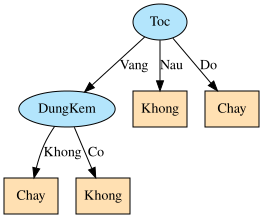

In [9]:
import graphviz

def add_nodes_edges(graph, node, node_id="root", branch_label=None, parent_id=None):
    if node["leaf"]:
        graph.node(node_id, node["label"], shape="box", style="filled", fillcolor="#ffe0b2")
    else:
        graph.node(node_id, node["attribute"], shape="ellipse", style="filled", fillcolor="#b3e5fc")

    if parent_id is not None:
        graph.edge(parent_id, node_id, label=str(branch_label))

    if not node["leaf"]:
        for i, (value, child) in enumerate(node["branches"].items()):
            child_id = f"{node_id}_{i}"
            add_nodes_edges(graph, child, child_id, branch_label=value, parent_id=node_id)

dot = graphviz.Digraph()
add_nodes_edges(dot, tree)
dot

BƯỚC 8 — Sinh luật phân loại (Decision Rules) từ cây

In [10]:
def extract_rules(node, path=None, rules=None):
    if path is None:
        path = []
    if rules is None:
        rules = []

    if node["leaf"]:
        condition = " AND ".join([f"{attr} = {val}" for attr, val in path])
        rules.append(f"IF {condition} THEN {TARGET} = {node['label']}")
        return rules

    for value, child in node["branches"].items():
        extract_rules(child, path + [(node["attribute"], value)], rules)

    return rules

rules = extract_rules(tree)
print(f"=== {len(rules)} LUẬT PHÂN LOẠI RÚT RA TỪ CÂY ===\n")
for i, r in enumerate(rules, start=1):
    print(f"R{i}: {r}")

print("\n(Kỳ vọng theo lý thuyết: 4 luật, ví dụ 'IF Toc=Nau THEN KetQua=Khong', 'IF Toc=Do THEN KetQua=Chay'...)")

=== 4 LUẬT PHÂN LOẠI RÚT RA TỪ CÂY ===

R1: IF Toc = Vang AND DungKem = Khong THEN KetQua = Chay
R2: IF Toc = Vang AND DungKem = Co THEN KetQua = Khong
R3: IF Toc = Nau THEN KetQua = Khong
R4: IF Toc = Do THEN KetQua = Chay

(Kỳ vọng theo lý thuyết: 4 luật, ví dụ 'IF Toc=Nau THEN KetQua=Khong', 'IF Toc=Do THEN KetQua=Chay'...)


BƯỚC 9 — Hàm dự đoán (Predict) & kiểm tra độ chính xác trên tập huấn luyện

In [11]:
def predict(node, sample: dict):
    if node["leaf"]:
        return node["label"]

    attr = node["attribute"]
    value = sample.get(attr)

    if value in node["branches"]:
        return predict(node["branches"][value], sample)
    else:
        return node["majority"]

correct = 0
print(f"{'Tên':10s}{'Thực tế':10s}{'Dự đoán':10s}{'Đúng?':6s}")
for name, row in df.iterrows():
    sample = row.to_dict()
    pred = predict(tree, sample)
    is_correct = (pred == row[TARGET])
    correct += is_correct
    print(f"{name:10s}{row[TARGET]:10s}{pred:10s}{'✓' if is_correct else '✗':6s}")

print(f"\nĐộ chính xác trên tập huấn luyện: {correct}/{len(df)} = {correct/len(df)*100:.1f}%")
print("(Kỳ vọng theo lý thuyết: 8/8 = 100%)")

Tên       Thực tế   Dự đoán   Đúng? 
Sarah     Chay      Chay      ✓     
Dana      Khong     Khong     ✓     
Alex      Khong     Khong     ✓     
Annie     Chay      Chay      ✓     
Emilie    Chay      Chay      ✓     
Peter     Khong     Khong     ✓     
John      Khong     Khong     ✓     
Kartie    Khong     Khong     ✓     

Độ chính xác trên tập huấn luyện: 8/8 = 100.0%
(Kỳ vọng theo lý thuyết: 8/8 = 100%)


BƯỚC 10 — Nhập một trường hợp bất kỳ để kiểm tra kết quả

In [12]:
def input_with_options(attr_name, options):
    options_str = " / ".join(options)
    while True:
        value = input(f"Nhập {attr_name} ({options_str}): ").strip()
        matched = [o for o in options if o.lower() == value.lower()]
        if matched:
            return matched[0]
        print(f"  -> Giá trị không hợp lệ, vui lòng chọn trong: {options_str}")


def predict_with_path(node, sample: dict, path=None):
    if path is None:
        path = []
    if node["leaf"]:
        return node["label"], path

    attr = node["attribute"]
    value = sample.get(attr)
    path = path + [f"{attr}={value}"]

    if value in node["branches"]:
        return predict_with_path(node["branches"][value], sample, path)
    else:
        return node["majority"], path + ["(giá trị lạ -> dùng lớp đa số)"]


print("===== NHẬP TRƯỜNG HỢP MỚI ĐỂ DỰ ĐOÁN =====")
new_sample = {}
for attr in ATTRIBUTES:
    options = sorted(df[attr].unique())
    new_sample[attr] = input_with_options(attr, options)

label, path = predict_with_path(tree, new_sample)

print("\n--- KẾT QUẢ ---")
print("Mẫu vừa nhập:", new_sample)
print("Đường đi trên cây:", " -> ".join(path))
print(f"\n=> DỰ ĐOÁN: {TARGET} = {label}")

===== NHẬP TRƯỜNG HỢP MỚI ĐỂ DỰ ĐOÁN =====
Nhập Toc (Do / Nau / Vang): Do
Nhập ChieuCao (Cao / TBinh / Thap): Cao
Nhập CanNang (Nang / Nhe / TBinh): TBinh
Nhập DungKem (Co / Khong): Co

--- KẾT QUẢ ---
Mẫu vừa nhập: {'Toc': 'Do', 'ChieuCao': 'Cao', 'CanNang': 'TBinh', 'DungKem': 'Co'}
Đường đi trên cây: Toc=Do

=> DỰ ĐOÁN: KetQua = Chay


BƯỚC 11 — (Mở rộng) So sánh Vector Đặc Trưng với Entropy/Information Gain

In [13]:
import math

def entropy(labels):
    labels = pd.Series(labels)
    total = len(labels)
    counts = labels.value_counts()
    ent = 0.0
    for c in counts:
        p = c / total
        ent -= p * math.log2(p)
    return ent

def information_gain(data, attribute, target):
    total_entropy = entropy(data[target])
    total_len = len(data)
    weighted = 0.0
    for value in data[attribute].unique():
        subset = data[data[attribute] == value]
        weighted += (len(subset) / total_len) * entropy(subset[target])
    return total_entropy - weighted

print("So sánh Score (Vector Đặc Trưng) và Gain (Entropy) tại nút gốc:\n")
print(f"{'Thuộc tính':10s}{'Score':>10s}{'Gain':>10s}")
for attr in ATTRIBUTES:
    s = score(df, attr, TARGET, CLASSES)
    g = information_gain(df, attr, TARGET)
    print(f"{attr:10s}{s:10.3f}{g:10.3f}")

So sánh Score (Vector Đặc Trưng) và Gain (Entropy) tại nút gốc:

Thuộc tính     Score      Gain
Toc            0.750     0.454
ChieuCao       0.750     0.266
CanNang        0.625     0.016
DungKem        0.750     0.348


BÀI TẬP MỞ RỘNG (TỰ LÀM THÊM)

1.Đổi vai trò lớp mục tiêu (thử hoán đổi thứ tự CLASSES) — kiểm tra Score có thay đổi không? Vì sao?

Vì sao?
Entropy và Information Gain chỉ phụ thuộc vào phân bố xác suất của các lớp, chứ không phụ thuộc vào việc ta gọi lớp đó là “Yes” hay “No”.

Khi bạn hoán đổi thứ tự hoặc đổi tên nhãn, các giá trị xác suất pᵢ vẫn giữ nguyên → Entropy và Gain không đổi → cấu trúc cây không đổi.

Do đó, số lượng dự đoán đúng trên tập huấn luyện vẫn giữ nguyên, nên Score không thay đổi.

Ví dụ minh họa
Bộ dữ liệu “Play Tennis” có 9 YES và 5 NO. Nếu bạn đổi nhãn thành “No/Yes” hoặc “Không chơi/Chơi”, thì phân bố vẫn là 9–5.

Entropy(S) vẫn ≈ 0.940, Gain(Outlook) vẫn ≈ 0.246.

Cây quyết định sinh ra giống hệt, chỉ khác tên nhãn lá.

Khi kiểm tra trên tập huấn luyện, vẫn đạt 14/14 đúng → Score = 100%.

Thử thêm một mẫu dữ liệu mới vào bảng gốc rồi chạy lại toàn bộ pipeline — quan sát cây có thay đổi không

Entropy và Gain phụ thuộc vào phân bố lớp:

Nếu mẫu mới có nhãn giống với xu hướng hiện tại (ví dụ thêm một mẫu “Sunny, High, Weak → No”), thì phân bố lớp không thay đổi nhiều → Entropy và Gain gần như giữ nguyên → cấu trúc cây thường không đổi.

Nếu mẫu mới đi ngược xu hướng (ví dụ thêm một mẫu “Sunny, High, Weak → Yes”), thì phân bố lớp thay đổi đáng kể → Entropy và Gain thay đổi → cây có thể chọn thuộc tính khác làm nút gốc hoặc thay đổi nhánh.

Cây ID3 rất nhạy với dữ liệu nhỏ:

Với tập 14 mẫu “Play Tennis”, chỉ cần thêm 1–2 mẫu mới là Entropy và Gain có thể thay đổi đủ để đảo thứ tự ưu tiên thuộc tính.

Do đó, cây có thể thay đổi cấu trúc, số luật, hoặc độ sâu.

Cài đặt thêm tiêu chí phụ thứ 2 khi vẫn còn đồng điểm sau bước "đếm nhóm thuần nhất" (ví dụ: ưu tiên thuộc tính có ít giá trị hơn)

In [14]:
def choose_best_attribute(data, attributes, target):
    # Tính Gain cho tất cả thuộc tính
    gains = {a: information_gain(data, a, target) for a in attributes}
    max_gain = max(gains.values())
    # Lọc ra các thuộc tính có Gain bằng max_gain
    candidates = [a for a, g in gains.items() if abs(g - max_gain) < 1e-9]
    if len(candidates) == 1:
        return candidates[0], gains[candidates[0]]
    else:
        # Tiêu chí phụ: chọn thuộc tính có ít giá trị hơn
        best_attr = min(candidates, key=lambda a: len(data[a].unique()))
        return best_attr, gains[best_attr]

def build_id3(data, attributes, target):
    labels = data[target].unique()
    if len(labels) == 1:
        return {"leaf": True, "label": labels[0]}
    if len(attributes) == 0:
        majority_label = data[target].value_counts().idxmax()
        return {"leaf": True, "label": majority_label}

    best_attr, best_gain = choose_best_attribute(data, attributes, target)
    node = {
        "leaf": False,
        "attribute": best_attr,
        "gain": best_gain,
        "branches": {},
        "majority": data[target].value_counts().idxmax(),
    }
    remaining_attrs = [a for a in attributes if a != best_attr]
    for value in data[best_attr].unique():
        subset = data[data[best_attr] == value]
        if len(subset) == 0:
            node["branches"][value] = {"leaf": True, "label": node["majority"]}
        else:
            node["branches"][value] = build_id3(subset, remaining_attrs, target)
    return node


Viết hàm tính độ sâu cây và so sánh độ sâu giữa cây Quinlan (Vector Đặc Trưng) và cây ID3 (Entropy) trên cùng 1 bộ dữ liệu

Hàm tính độ sâu

In [17]:
def tree_depth(node):
    """Tính độ sâu của cây ID3 tự cài đặt"""
    if node["leaf"]:
        return 1
    else:
        return 1 + max(tree_depth(child) for child in node["branches"].values())


Với cây của scikit-learn
Scikit-learn có sẵn thuộc tính .get_depth() trong đối tượng DecisionTreeClassifier.
Ví dụ:

In [19]:
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier

# Encode dữ liệu categorical
df_encoded = df.copy()
encoders = {}
for col in ATTRIBUTES + [TARGET]:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df[col])
    encoders[col] = le

# Chuẩn bị X và y
X = df_encoded[ATTRIBUTES]
y = df_encoded[TARGET]

# Huấn luyện cây với Entropy
clf_entropy = DecisionTreeClassifier(criterion="entropy")
clf_entropy.fit(X, y)

# Huấn luyện cây với Gini
clf_gini = DecisionTreeClassifier(criterion="gini")
clf_gini.fit(X, y)

print("Độ sâu cây ID3 (Entropy):", clf_entropy.get_depth())
print("Độ sâu cây Quinlan/CART (Gini):", clf_gini.get_depth())


Độ sâu cây ID3 (Entropy): 3
Độ sâu cây Quinlan/CART (Gini): 3
